# Salary model – PCA skill embedding (Chapter 1)

This notebook builds the **PCA-based skill representation** that will be used across the project for salary modelling and later individual positioning.

**Goals**

- Reduce the original 27 binary skill features into a smaller set of continuous components.
- Choose a sensible number of principal components that retain most of the variance.
- Save the fitted PCA model and its training data so the transformation can be reused in `src/`.
- Append the resulting PCA axes to the main salary-modelling dataframe.

**Workflow**

1. **Prepare skill matrix**  
   - Extract the 27 skill columns (0/1 indicators) from the processed salary dataset.  
   - Confirm there are no missing values and that the column order is fixed and documented.

2. **Fit full PCA and inspect variance explained**  
   - Fit an unconstrained PCA on the full skill matrix.  
   - Examine the variance explained and cumulative variance for all components.  
   - Decide to retain **10 principal components**, which capture ~70% of the total variance and provide a good trade-off between dimensionality reduction and information loss.

3. **Refit PCA with 10 components**  
   - Refit a simpler PCA model with `n_components = 10` on the same skill matrix.  
   - Inspect component loadings to ensure the axes are interpretable as latent “skill dimensions”.

4. **Save PCA artefacts for reuse**  
   - Save the fitted PCA object to `models/skill_pca_v1.pkl`.  
   - Save the exact skill feature matrix used to train PCA to `data/processed/skill_df_v01.csv`.  
   - These artefacts lock in the skill space so future jobs and individual profiles can be projected into the **same** 10-dimensional PCA space.

5. **Append PCA axes to salary dataset**  
   - Transform the full skill matrix using the 10-component PCA model.  
   - Create `skill_PC1` … `skill_PC10` and append them to the main salary-modelling dataframe.  
   - Save this enriched dataset as a new processed file (e.g. `salary_model_df_v04_pca.csv`) for use in **Salary Model v4**.

**Outcome**

This notebook produces a stable, reusable **skill embedding layer**:  
a fitted PCA model + training data + a salary dataset augmented with 10 interpretable skill components. These components will be used in the next notebook to refit the salary model (Model v4) and to provide a consistent representation of skills for future users and job postings.


## Set up

* Libraries
* Path
* Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

from src.job_intel.config import CH1_PROCESSED_SALARY_MODEL_DF

In [3]:
df_ch0 = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_DF)
df_ch0.head()

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,job_title_family_data_scientist,job_title_family_scientist,title_rich,size_code,sector_code,state_code,ownership_code,seniority_code,title_code,title_rich_code
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,1,0,general_data_data_scientist,5,24,11,2,7,2,10
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,1,0,business_data_scientist,2,7,11,2,9,2,6
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,1,0,general_data_data_scientist,0,25,11,4,4,2,10
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0,0,general_data_data_analyst,3,12,10,2,5,0,8
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,1,0,general_data_data_scientist,6,5,11,2,4,2,10


## Skill data

In [4]:
skills = df_ch0[[
            # Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none'
            ]].copy() 

#### Save the data for the feature later - this data reproduces the PCA

In [5]:
from src.job_intel.config import PROCESSED_DATA_DIR
skills.to_csv(PROCESSED_DATA_DIR / 'skills_df_v01.csv', index=False)

## Build and fit the full PCA

In [6]:
from sklearn.decomposition import PCA

In [7]:
pca_full = PCA()
pca_full.fit(skills)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


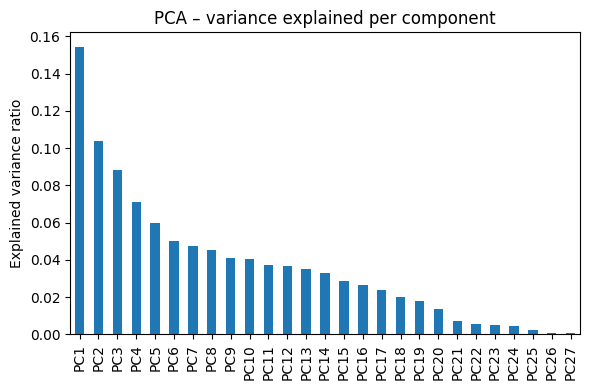

In [8]:
explained = pd.Series(
    pca_full.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))]
)

plt.figure(figsize=(6, 4))
explained.plot(kind="bar")
plt.ylabel("Explained variance ratio")
plt.title("PCA – variance explained per component")
plt.tight_layout()


PC1     0.154410
PC2     0.258168
PC3     0.346156
PC4     0.417406
PC5     0.477346
PC6     0.527568
PC7     0.574850
PC8     0.620309
PC9     0.661329
PC10    0.701780
PC11    0.739146
PC12    0.775902
PC13    0.810837
PC14    0.843945
PC15    0.872699
PC16    0.899219
PC17    0.922872
PC18    0.942857
PC19    0.960693
PC20    0.974274
PC21    0.981576
PC22    0.987151
PC23    0.991998
PC24    0.996490
PC25    0.998735
PC26    0.999413
PC27    1.000000
dtype: float64

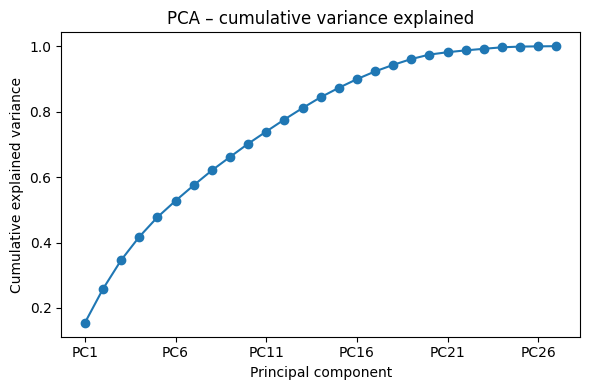

In [9]:
explained_cum = explained.cumsum()

plt.figure(figsize=(6, 4))
explained_cum.plot(marker="o")
plt.ylabel("Cumulative explained variance")
plt.xlabel("Principal component")
plt.title("PCA – cumulative variance explained")
plt.tight_layout()
explained_cum

## Simplified PCA

### We will choose 10 PC to add up to 70% of variability
#### Create and save the output for individual skill input later in the project

In [10]:
pca = PCA(n_components=10, random_state=101)
pca.fit(skills)


,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,101


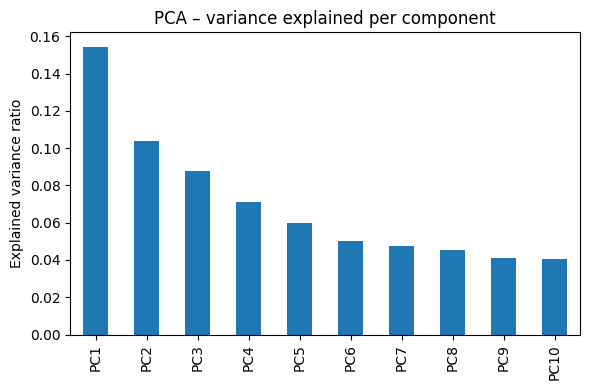

In [11]:
explained = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))]
)

plt.figure(figsize=(6, 4))
explained.plot(kind="bar")
plt.ylabel("Explained variance ratio")
plt.title("PCA – variance explained per component")
plt.tight_layout()

PC1     0.154410
PC2     0.258168
PC3     0.346156
PC4     0.417406
PC5     0.477346
PC6     0.527568
PC7     0.574850
PC8     0.620309
PC9     0.661329
PC10    0.701780
dtype: float64

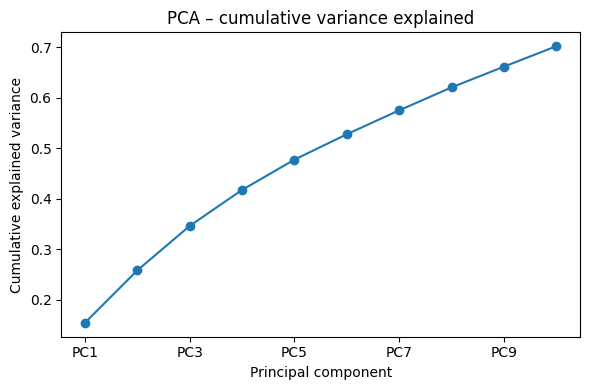

In [12]:
explained_cum = explained.cumsum()

plt.figure(figsize=(6, 4))
explained_cum.plot(marker="o")
plt.ylabel("Cumulative explained variance")
plt.xlabel("Principal component")
plt.title("PCA – cumulative variance explained")
plt.tight_layout()
explained_cum

### Save model for feature

In [13]:
import joblib
from src.job_intel.config import MODELS_DIR
joblib.dump(pca, MODELS_DIR / "skill_pca_v1.pkl")

['/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/models/skill_pca_v1.pkl']

### Transform data and add it to the main dataframe

In [ ]:
skills_pca = pca.transform(skills)   # shape: (n_jobs, 10)
pca_cols = [f"skill_PC{i+1}" for i in range(10)]

df_skills_pca = pd.DataFrame(skills_pca,
                             columns=pca_cols,
                             index=skills.index)

,core_programming__basic,core_programming__intermediate,core_programming__advanced,data_engineering_pipelines__basic,data_engineering_pipelines__intermediate,data_engineering_pipelines__advanced,ml_ai__basic,ml_ai__intermediate,ml_ai__advanced,analytics_stats__basic,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
0,1,0,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,1,0,0,1,...,0,1,0,0,0,0,0,1,0,0
2,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,1,1
3,1,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,1,1,0
4,1,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6156,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6157,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,0
6158,0,0,0,0,1,0,0,0,0,1,...,0,1,0,0,1,0,0,1,1,1
6159,1,0,0,0,1,0,0,0,0,1,...,0,1,1,0,0,0,0,1,1,0


In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=skills.columns,
    columns=[f"PC{i+1}" for i in range(10)]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
core_programming__basic,0.423727,-0.124008,0.285786,-0.262649,-0.003284,-0.091759,0.341033,-0.435815,0.247358,-0.292232
core_programming__intermediate,0.139735,-0.102665,-0.014122,0.038017,0.030661,0.038589,0.050609,-0.017441,0.075627,-0.131663
core_programming__advanced,0.001854,-0.003711,0.001158,0.000208,0.000832,0.001625,0.000868,0.002211,0.003578,-0.001169
data_engineering_pipelines__basic,0.007271,0.007022,-0.013100,0.010150,0.000656,0.004248,0.008360,0.007913,0.015081,-0.000478
data_engineering_pipelines__intermediate,0.438001,-0.114083,-0.254168,0.202403,-0.069888,0.273704,-0.096935,0.225777,-0.291864,-0.367351
data_engineering_pipelines__advanced,0.223082,-0.099995,0.018525,0.181114,-0.100865,0.233552,0.038472,-0.239834,0.042394,0.099825
ml_ai__basic,0.145699,-0.120309,0.432614,-0.063083,-0.070631,-0.002067,-0.404033,0.047760,-0.222949,0.059303
ml_ai__intermediate,0.152610,-0.123969,0.415988,-0.115643,-0.050566,-0.051853,-0.415518,0.028178,-0.149255,0.041405
ml_ai__advanced,0.081754,-0.110176,0.208863,-0.006450,-0.039371,0.017795,-0.178220,-0.017534,-0.044040,0.071349
analytics_stats__basic,0.180525,0.289254,0.396368,0.010952,-0.143344,0.302165,0.472641,0.564250,-0.028823,0.185006


In [16]:
df_ch1 = df_ch0.copy()
df_ch1[pca_cols] = df_skills_pca
df_ch1.head()

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,skill_PC1,skill_PC2,skill_PC3,skill_PC4,skill_PC5,skill_PC6,skill_PC7,skill_PC8,skill_PC9,skill_PC10
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,0.462016,0.107793,-0.286497,-0.961280,0.050588,-0.055616,0.395975,0.480314,0.016349,-0.239943
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,0.018662,-0.339362,0.631396,-0.972227,-0.139904,-0.183168,0.286340,0.235295,0.125379,0.213347
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,-0.485473,-0.143990,0.604327,0.428753,0.363498,-0.395078,0.811758,0.003043,0.025900,-0.188561
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0.009683,1.123316,0.112544,-0.535952,-0.301241,-0.235044,0.295499,-0.211524,0.196350,-0.283105
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,-0.502115,-0.138427,0.758690,-0.065791,-0.458638,-0.280799,-0.722739,-0.690126,0.256452,-0.619181


In [17]:
from src.job_intel.config import PROCESSED_DATA_DIR
df_ch1.to_csv(PROCESSED_DATA_DIR / 'salary_model_dfv02_pca.csv', index=False)

# === End of Notebook ===